In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix

In [2]:
import astroML as aML

Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



In [3]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

C:\Users\annat\AppData\Local\Temp\ipykernel_3524\3973052632.py:9: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [4]:
data

array([['GRB260429A', 'GRB260428A', 'GRB260424B', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'],
       ['GRB260429975', 'GRB260428598', 'None', ..., 'None', 'None',
        'None'],
       ['23:24:02', '14:20:35', '23:37:22.824', ..., '19:43:25.064',
        '19:51:15.804', '9:14:03.800'],
       ...,
       ['0.1610', '4.5870', '-999', ..., '3.1360', '208.5760', '5.6960'],
       ['False', 'False', 'False', ..., 'False', 'False', 'False'],
       ['61159.97502315', '61158.59762731', '61154.98429194', ...,
        '48370.82181787', '48369.82726625', '48367.38476620']],
      shape=(15, 9090), dtype='<U14')

In [5]:
data.shape

(15, 9090)

In [6]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

In [7]:
data_merged=dict(zip(names,data))
for label in ['T90', 'T90_error', "'T100'", 'fluence', 'fluence_error']:
    data_merged[label] = np.array(data_merged[label],dtype='float')

 ## KMeans

Start doing some naif exploration of data by trying a 2 cluster fit (as I know from theory there should be two types, long and short GRBs)

C:\Users\annat\AppData\Local\Temp\ipykernel_3524\3990865622.py:1: RuntimeWarning: invalid value encountered in log10
  log_T90 = np.log10(data_merged["T90"])
C:\Users\annat\AppData\Local\Temp\ipykernel_3524\3990865622.py:2: RuntimeWarning: divide by zero encountered in log10
  log_fluence = np.log10(data_merged['fluence'])
C:\Users\annat\AppData\Local\Temp\ipykernel_3524\3990865622.py:2: RuntimeWarning: invalid value encountered in log10
  log_fluence = np.log10(data_merged['fluence'])


Text(0, 0.5, 'log10(fluence)')

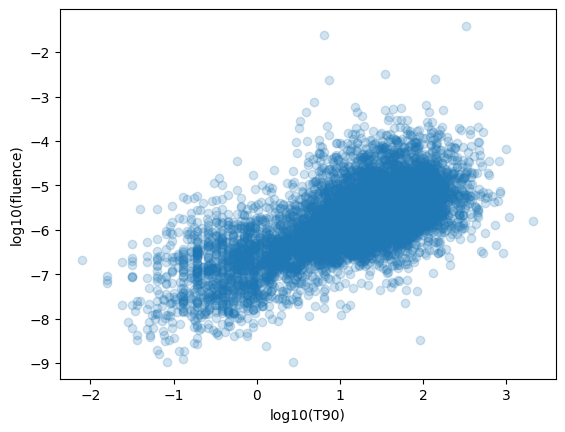

In [8]:
log_T90 = np.log10(data_merged["T90"])
log_fluence = np.log10(data_merged['fluence'])
index_to_cut = np.where(np.isnan(log_T90) | np.isinf(log_T90))[0]
log_T90 = np.delete(log_T90, index_to_cut)
log_fluence = np.delete(log_fluence, index_to_cut)
index_to_cut =   np.where(np.isnan(log_fluence) | np.isinf(log_fluence))[0]
log_T90 = np.delete(log_T90, index_to_cut)
log_fluence = np.delete(log_fluence, index_to_cut)

plt.scatter(log_T90, log_fluence, alpha=0.2)
plt.xlabel('log10(T90)')
plt.ylabel('log10(fluence)')

In [9]:
X = np.stack((log_T90, log_fluence)).T

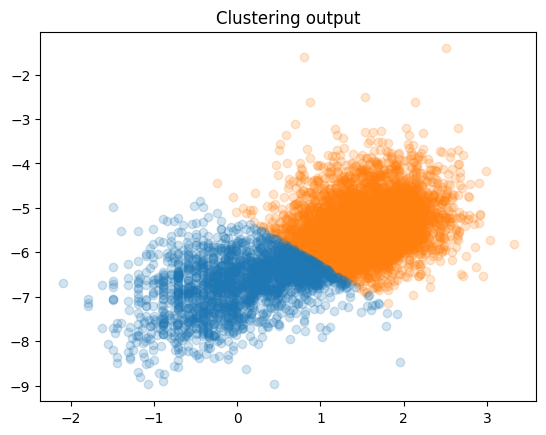

In [111]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.2)

# To get some information on these try:
# KMeans?
# help(clf)
plt.title('Clustering output');

In [11]:
import os
import warnings

# Just things to take away all the error messages
os.environ['OMP_NUM_THREADS'] = '1' 
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

In [59]:
centers

array([[ 1.52144551, -5.45182655],
       [ 0.05999589, -6.71119574]])

Cross validation for the number of clusters. I've used Grid Search algorithm to do 5 folds of validation on a score metric based on silhouette value. I found it is used to define the goodness of clustering divisions: it computes the score in a geometrical fashion, I'd say, looking at its shape. distance from center of it and from neighbours.

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score, make_scorer

# Numbers to test
k_range = range(2, 10)

# Function to define a score by using Silhoutte, higher it is the better (and GridSearch takes
# the maximum)
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    # At least 2 clusters
    if len(np.unique(labels)) < 2:
        return -1 
    return silhouette_score(X, labels)

# GridSearch with 5 folds
grid_km = GridSearchCV(
    KMeans(n_init='auto', random_state=42),
    param_grid={'n_clusters': k_range},
    scoring=silhouette_scorer,
    cv=5 
)

# Fit on data
grid_km.fit(X)

best_k = grid_km.best_params_['n_clusters']
print(f"The best number of clusters for KMeans from Cross Validation is: {best_k}")

The best number of clusters for KMeans from Cross Validation is: 2


## MeanShift

Start by prepocessing and standardizing data and performing an estimation for the best bandwith of the 2d kde describing the data

In [140]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [142]:
from sklearn.cluster import estimate_bandwidth

# increment quantile to merge small clusters together
bw = estimate_bandwidth(X_scaled, quantile=0.5, n_samples=500)

ms = MeanShift(bandwidth=bw, bin_seeding=True)#, cluster_all=False)#, min_bin_freq=3)
ms.fit(X_scaled)

print(f"Best bandwidth: {bw:.3f}")
print(f"Clusters found: {len(np.unique(ms.labels_))}")

Best bandwidth: 2.213
Clusters found: 2


[0 1]


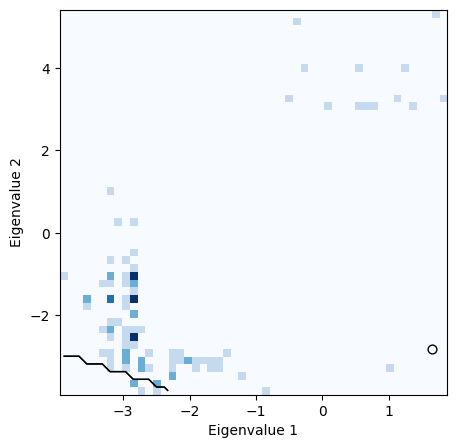

In [143]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)

# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X_scaled[:,0], X_scaled[:,1], 50)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 50 * 50)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))

ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('Eigenvalue 1')
ax.set_ylabel('Eigenvalue 2')

plt.show()

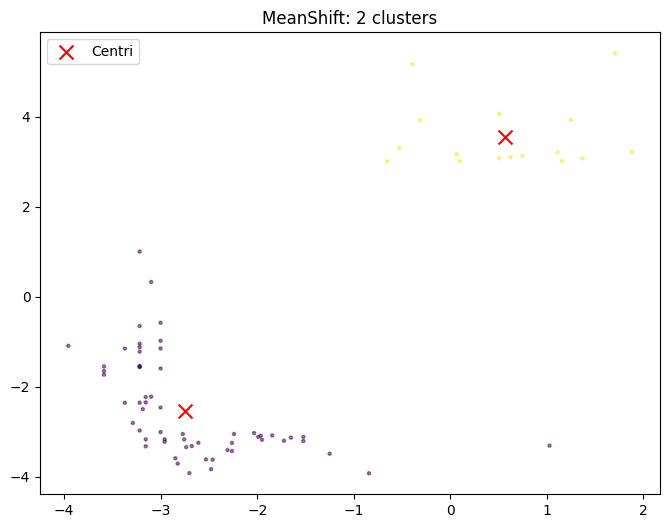

In [138]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=ms.labels_, s=5, cmap='viridis', alpha=0.5)
centers = ms.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=100, label='Centri')
plt.title(f"MeanShift: {len(np.unique(ms.labels_))} clusters")
plt.legend()
plt.show()

In [73]:
centers

array([[0.37073009, 0.23316312],
       [1.7046211 , 5.40655599]])

(array([7.343e+03, 2.460e+02, 9.200e+01, 4.200e+01, 1.200e+01, 1.000e+01,
        9.000e+00, 4.000e+00, 3.000e+00, 2.000e+00]),
 array([0.   , 0.003, 0.006, 0.009, 0.012, 0.015, 0.018, 0.021, 0.024,
        0.027, 0.03 ]),
 <BarContainer object of 10 artists>)

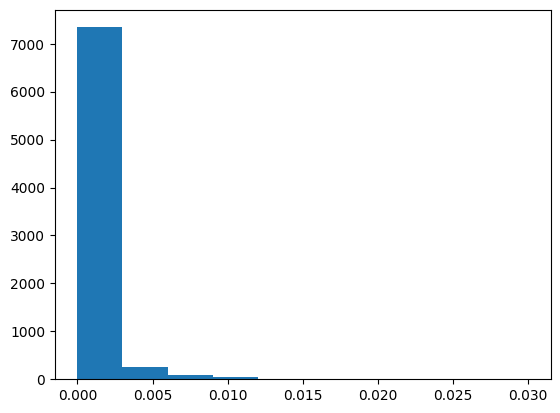

In [74]:
plt.hist(np.diff(np.sort(X_scaled[:,0])), range=(0,0.03))

## DB scan only tried, no results

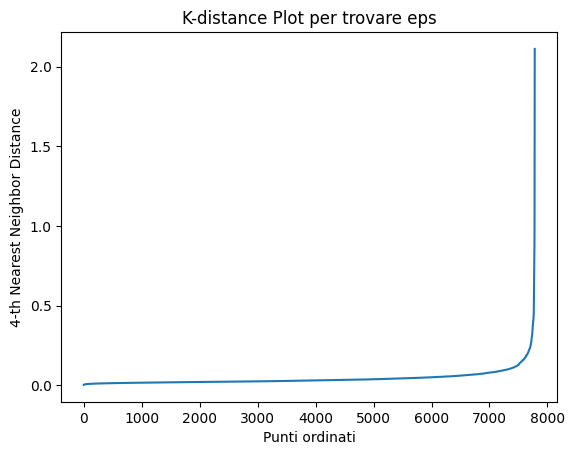

In [113]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# 1. Calcolo della distanza dai k vicini per trovare eps
# Un buon valore per k è 2 * dimensioni_dati = 4
neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Ordiniamo le distanze e plotteiamole
distances = np.sort(distances[:, 3], axis=0)
plt.plot(distances)
plt.ylabel('4-th Nearest Neighbor Distance')
plt.xlabel('Punti ordinati')
plt.title('K-distance Plot per trovare eps')
plt.show()

Cluster trovati: 1
Numero di cluster stimati: 1


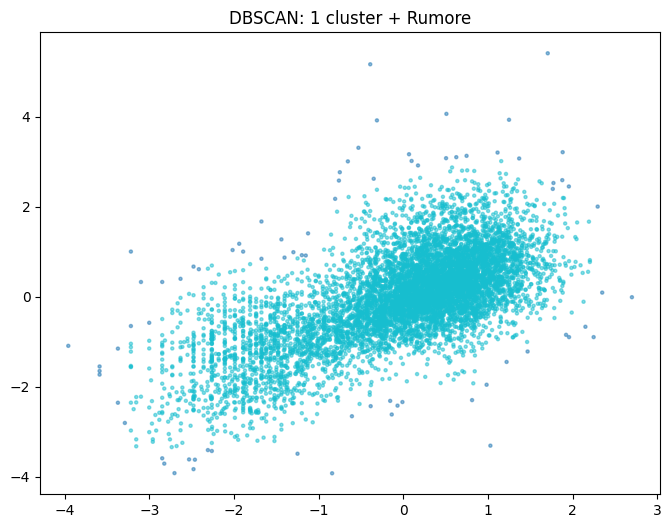

In [118]:

# Prova a ridurre eps e aumentare min_samples contemporaneamente
db = DBSCAN(eps=0.3, min_samples=10) 
labels_db = db.fit_predict(X_scaled)

print(f"Cluster trovati: {len(np.unique(labels_db[labels_db != -1]))}")

# Nota: le label -1 sono considerate "Rumore" (Outliers)
n_clusters_ = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f'Numero di cluster stimati: {n_clusters_}')

# Visualizzazione
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_db, s=5, cmap='tab10', alpha=0.5)
plt.title(f"DBSCAN: {n_clusters_} cluster + Rumore")
plt.show()

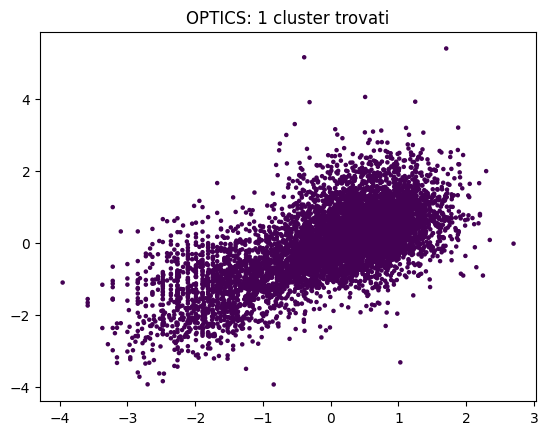

In [119]:
from sklearn.cluster import OPTICS

# OPTICS non richiede eps, cerca di capire la struttura gerarchica
op = OPTICS(min_samples=30, xi=0.05, min_cluster_size=0.05)
labels_op = op.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_op, s=5, cmap='viridis')
plt.title(f"OPTICS: {len(np.unique(labels_op[labels_op != -1]))} cluster trovati")
plt.show()

In [78]:
from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.15, min_samples=10).fit(X_scaled)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 4
Estimated number of noise points: 398


In [79]:
# Nota: usiamo log10(2) perché i nostri dati X sono in scala logaritmica
log_threshold = np.log10(2.0)

# y_true sarà 1 per i Long e 0 per i Short
# Assumiamo che X[:, 0] sia la colonna dei log_T90
y_true = (X[:, 0] <= log_threshold).astype(int)

In [80]:
y_true

array([1, 0, 1, ..., 0, 0, 0], shape=(7782,))

In [81]:
print(f"Homogeneity: {metrics.homogeneity_score(y_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(y_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(y_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(y_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X_scaled, labels):.3f}")

Homogeneity: 0.032
Completeness: 0.064
V-measure: 0.043
Adjusted Rand Index: 0.117
Adjusted Mutual Information: 0.042
Silhouette Coefficient: -0.070


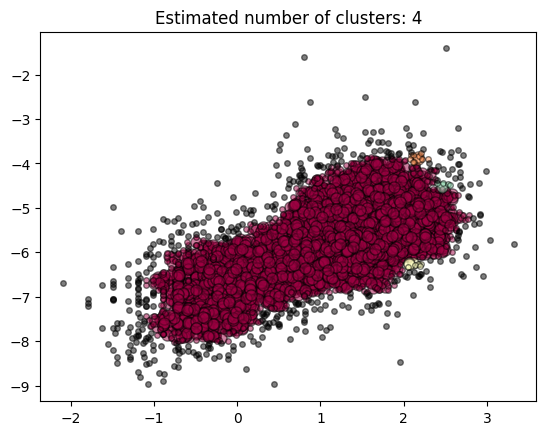

In [82]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=8, alpha=0.5
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=4, alpha=0.5
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

## Test and training

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.model_selection import KFold

# Metodo statistico: stima basata sui quantili dei dati
best_bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=500)
print(f"Stima ottimale della bandwidth: {best_bandwidth:.3f}")

ms = MeanShift(bandwidth=best_bandwidth, bin_seeding=True)
ms.fit(X)

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split 80/20
X_train, X_test = train_test_split(X, test_size=0.5)#, random_state=42)

# Training sul 80%
km_final = KMeans(n_clusters=2, n_init='auto').fit(X_train)

# Valutazione: assegniamo i punti del test set ai cluster trovati nel training
y_test_pred = km_final.predict(X_test)

# Se vuoi un'accuratezza numerica rispetto alla soglia fisica di 2s (T90):
log_threshold = np.log10(2.0)
y_test_true = (X_test[:, 0] > log_threshold).astype(int)

# Allineamento etichette (per evitare che 0 e 1 siano scambiati)
if km_final.cluster_centers_[0, 0] > km_final.cluster_centers_[1, 0]:
    y_test_pred = 1 - y_test_pred

acc = accuracy_score(y_test_true, y_test_pred)
print(f"Accuratezza del clustering (vs fisica): {acc:.2%}")

Accuratezza del clustering (vs fisica): 89.31%


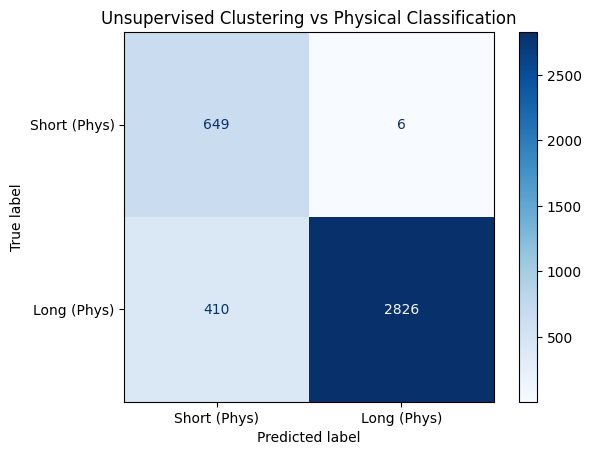

In [102]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcolo della matrice
cm = confusion_matrix(y_test_true, y_test_pred)

# Visualizzazione
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Short (Phys)', 'Long (Phys)'])
disp.plot(cmap='Blues')
plt.title('Unsupervised Clustering vs Physical Classification')
plt.show()

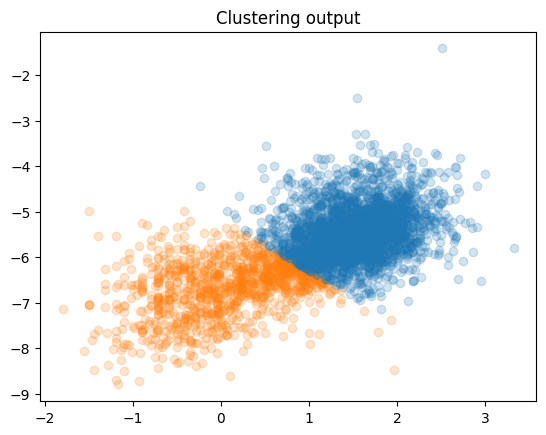

In [103]:
centers = km_final.cluster_centers_ #location of the clusters


# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X_test[y_test_pred==ii,0], X_test[y_test_pred==ii,1], 
                color=colors[ii],alpha=0.2)

# To get some information on these try:
# KMeans?
# help(clf)
plt.title('Clustering output');

## Correlation

In [120]:

import pandas as pd
from astroML.correlation import two_point

# nomi delle colonne basati sulla tua descrizione
cols = ['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
        'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
        'redshift', 'T100', 'GBM_located', 'mjd_T0']

# Supponendo che 'data_array' sia il tuo array shape (15, 9090)
df = pd.DataFrame(data.T, columns=cols)

# Convertiamo in numerico le colonne necessarie (gestendo eventuali errori)
numeric_cols = ['ra', 'decl', 'T90', 'fluence']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Rimuoviamo righe con NaN (fondamentale per l'analisi di correlazione)
df_clean = df.dropna(subset=['ra', 'decl', 'T90'])

C:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


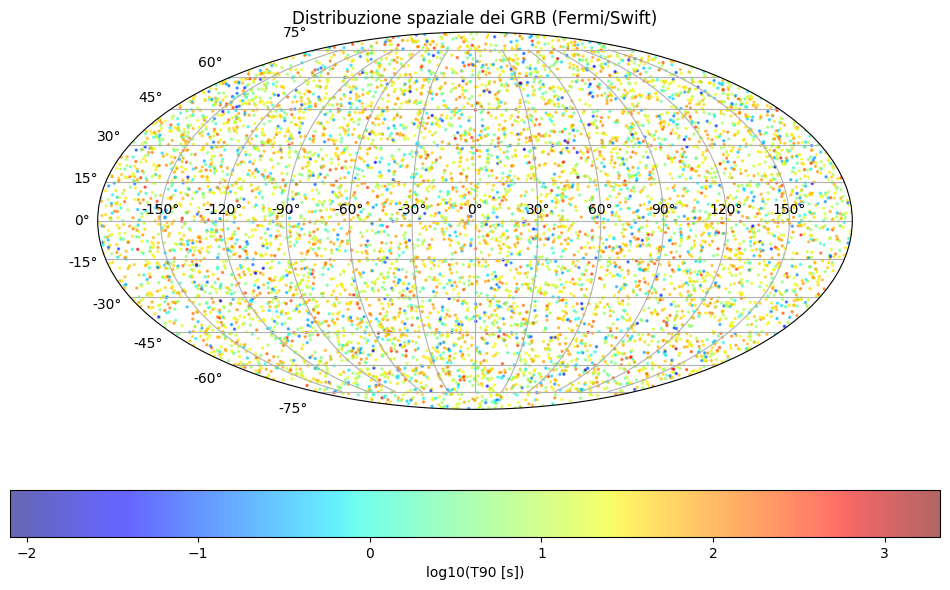

In [121]:
plt.figure(figsize=(12, 7))
ax = plt.subplot(111, projection='mollweide')

# Conversione RA/Dec in radianti
ra_rad = np.remainder(np.deg2rad(df_clean['ra']) + np.pi, 2*np.pi) - np.pi
dec_rad = np.deg2rad(df_clean['decl'])

# Usiamo il logaritmo del T90 per vedere meglio la distinzione Short/Long
sc = ax.scatter(ra_rad, dec_rad, c=np.log10(df_clean['T90']), 
                s=2, cmap='jet', alpha=0.6)

plt.colorbar(sc, label='log10(T90 [s])', orientation='horizontal')
plt.grid(True)
plt.title("Distribuzione spaziale dei GRB (Fermi/Swift)")
plt.show()

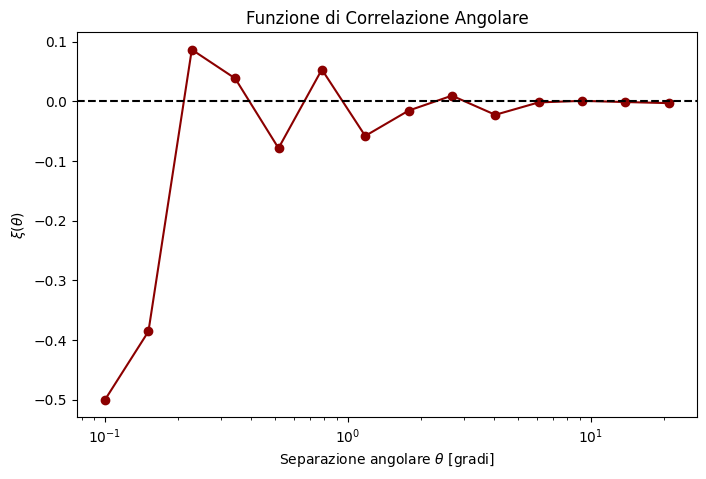

In [107]:
from astroML.correlation import two_point

# Prepariamo le coordinate sulla sfera
coords = df_clean[['ra', 'decl']].values

# Definiamo i bin angolari (in gradi)
bins = np.logspace(-1, 1.5, 15)

# Calcoliamo la correlazione
# Questa funzione confronta la distribuzione reale con una casuale (Random)
corr = two_point(coords, bins, method='landy-szalay')

plt.figure(figsize=(8, 5))
plt.semilogx(bins[:-1], corr, 'o-', color='darkred')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Separazione angolare $\\theta$ [gradi]')
plt.ylabel('$\\xi(\\theta)$')
plt.title('Funzione di Correlazione Angolare')
plt.show()

In [122]:
# Assumiamo che X_scaled siano i tuoi dati [log_T90, log_fluence] standardizzati
# e labels_km siano le etichette del KMeans (0 per una classe, 1 per l'altra)

# Identifichiamo chi è Short e chi è Long in base al T90 medio
centroid_0 = X_scaled[labels_km == 0].mean(axis=0)
centroid_1 = X_scaled[labels_km == 1].mean(axis=0)

if centroid_0[0] < centroid_1[0]:
    X_short = X_scaled[labels_km == 0]
    X_long = X_scaled[labels_km == 1]
else:
    X_short = X_scaled[labels_km == 1]
    X_long = X_scaled[labels_km == 0]

print(f"Short GRBs: {len(X_short)} | Long GRBs: {len(X_long)}")

Short GRBs: 94 | Long GRBs: 7688


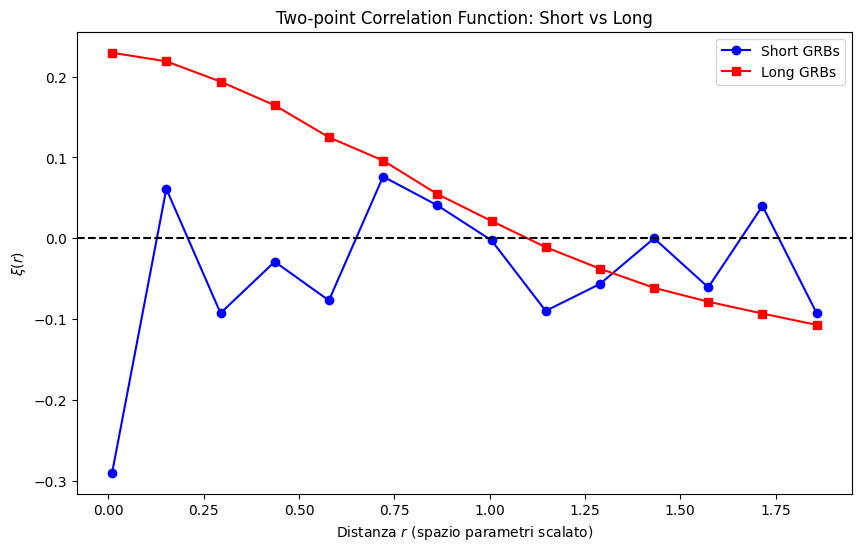

In [123]:
from astroML.correlation import two_point

# Definiamo i bins di distanza r (nello spazio dei parametri scalato)
bins = np.linspace(0.01, 2.0, 15)

# Calcolo per i Short
corr_short = two_point(X_short, bins, method='landy-szalay')

# Calcolo per i Long
corr_long = two_point(X_long, bins, method='landy-szalay')

# Plot dei risultati
plt.figure(figsize=(10, 6))
plt.plot(bins[:-1], corr_short, 'o-', label='Short GRBs', color='blue')
plt.plot(bins[:-1], corr_long, 's-', label='Long GRBs', color='red')

plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Distanza $r$ (spazio parametri scalato)')
plt.ylabel('$\\xi(r)$')
plt.title('Two-point Correlation Function: Short vs Long')
plt.legend()
plt.show()